In [1]:
import librosa # audio loading and feature extraction
import numpy as np# numerical arrays
import pandas as pd # dataframes
import matplotlib.pyplot as plt # plots
import os

In [ ]:
DATASET_PATH = r"C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original"
N_MFCC = 20

In [ ]:
# mfcc function to extract features from audio segments

def mfcc(segment, sample_rate, n_mfcc=N_MFCC):
    """
    Extract MFCC mean + std features from one audio segment.
    Returns a 1D feature vector.
    """
    mfcc_matrix = librosa.feature.mfcc(
        y=segment,
        sr=sample_rate,
        n_mfcc=n_mfcc
    )

    mfcc_mean = np.mean(mfcc_matrix, axis=1)
    mfcc_std = np.std(mfcc_matrix, axis=1)

    features = np.concatenate([mfcc_mean, mfcc_std])
    return features

In [ ]:
# Chroma and tonnetz features are also useful for music genre classification, but they need so much time

def mfcc_plus(segment, sample_rate, n_mfcc=N_MFCC):
    """
    Extract MFCC, chroma, and tonnetz features from one audio segment.
    Returns a 1D feature vector.
    """
    mfcc_matrix = librosa.feature.mfcc(
        y=segment,
        sr=sample_rate,
        n_mfcc=n_mfcc
    )

    chroma_matrix = librosa.feature.chroma_stft(
        y=segment,
        sr=sample_rate
    )

    tonnetz_matrix = librosa.feature.tonnetz(
        y=segment,
        sr=sample_rate
    )

    mfcc_mean = np.mean(mfcc_matrix, axis=1)
    mfcc_std = np.std(mfcc_matrix, axis=1)

    chroma_mean = np.mean(chroma_matrix, axis=1)
    chroma_std = np.std(chroma_matrix, axis=1)

    tonnetz_mean = np.mean(tonnetz_matrix, axis=1)
    tonnetz_std = np.std(tonnetz_matrix, axis=1)

    features = np.concatenate([
        mfcc_mean,
        mfcc_std,
        chroma_mean,
        chroma_std,
        tonnetz_mean,
        tonnetz_std
    ])
    return features

In [42]:
def add_gaussian_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    noisy_audio = audio + noise_factor * noise
    noisy_audio = np.clip(noisy_audio, -1.0, 1.0)
    return noisy_audio

In [ ]:
def load_data_plus(dataset_path=DATASET_PATH,
               n_mfcc=N_MFCC,
               segment_duration=None,
               overlap_duration=0.0,
               augment=False,
               noise_factor=0.005,
               augment_copies=1):
    """
    Load the dataset and extract a richer feature set with MFCC, chroma and tonnetz.

    It goes through each genre folder, and for each audio file,
    it extracts features using mfcc_other and stores them together with
    the corresponding genre labels.

    Parameters
    ----------
    segment_duration : float or None
        If None, each file is processed as a whole.
        If a number (e.g. 10.0), each audio file is split into
        fixed-length segments.

    overlap_duration : float
        Overlap between consecutive segments in seconds.
        Example:
        segment_duration=10.0, overlap_duration=2.0
        -> segments like 0-10, 8-18, 16-26, ...
        Default is 0.0 (no overlap).

    augment : bool
        If True, Gaussian-noise augmented copies are added.

    noise_factor : float
        Strength of the Gaussian noise.

    augment_copies : int
        Number of noisy copies generated per original sample.
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            if not file_path.endswith(".wav"):
                continue

            try:
                audio, sample_rate = librosa.load(file_path, sr=None)
            except Exception as e:
                print(f"Skipping {file_path} due to load error: {e}")
                continue

            if segment_duration is None:
                features_single = mfcc_plus(
                    segment=audio,
                    sample_rate=sample_rate,
                    n_mfcc=n_mfcc
                )

                features.append(features_single)
                labels.append(genre)

                if augment:
                    for _ in range(augment_copies):
                        noisy_audio = add_gaussian_noise(audio, noise_factor=noise_factor)

                        noisy_features = mfcc_plus(
                            segment=noisy_audio,
                            sample_rate=sample_rate,
                            n_mfcc=n_mfcc
                        )

                        features.append(noisy_features)
                        labels.append(genre)

            else:
                samples_per_segment = int(sample_rate * segment_duration)
                samples_overlap = int(sample_rate * overlap_duration)
                step = samples_per_segment - samples_overlap

                if step <= 0:
                    raise ValueError("overlap_duration must be smaller than segment_duration")

                if len(audio) < samples_per_segment:
                    continue

                for start in range(0, len(audio) - samples_per_segment + 1, step):
                    end = start + samples_per_segment
                    segment = audio[start:end]

                    features_single = mfcc_plus(
                        segment=segment,
                        sample_rate=sample_rate,
                        n_mfcc=n_mfcc
                    )

                    features.append(features_single)
                    labels.append(genre)

                    if augment:
                        for _ in range(augment_copies):
                            noisy_segment = add_gaussian_noise(segment, noise_factor=noise_factor)

                            noisy_features = mfcc_plus(
                                segment=noisy_segment,
                                sample_rate=sample_rate,
                                n_mfcc=n_mfcc
                            )

                            features.append(noisy_features)
                            labels.append(genre)

    return np.array(features), np.array(labels)

In [ ]:
def load_data_gaussian_noise(dataset_path=DATASET_PATH,
               n_mfcc=N_MFCC,
               segment_duration=None,
               overlap_duration=0.0,
               augment=False,
               noise_factor=0.005,
               augment_copies=1):
    """
    Load the dataset and extract features and labels.

    It goes through each genre folder, and for each audio file,
    it extracts MFCC-based features and stores them together with
    the corresponding genre labels.

    Parameters
    ----------
    segment_duration : float or None
        If None, each file is processed as a whole.
        If a number (e.g. 10.0), each audio file is split into
        fixed-length segments.

    overlap_duration : float
        Overlap between consecutive segments in seconds.
        Example:
        segment_duration=10.0, overlap_duration=2.0
        -> segments like 0-10, 8-18, 16-26, ...
        Default is 0.0 (no overlap).

    augment : bool
        If True, Gaussian-noise augmented copies are added.

    noise_factor : float
        Strength of the Gaussian noise.

    augment_copies : int
        Number of noisy copies generated per original sample.
    """

    features = []
    labels = []

    for genre in os.listdir(dataset_path):
        genre_path = os.path.join(dataset_path, genre)

        if not os.path.isdir(genre_path):
            continue

        for file in os.listdir(genre_path):
            file_path = os.path.join(genre_path, file)

            if not file_path.endswith(".wav"):
                continue

            try:
                audio, sample_rate = librosa.load(file_path, sr=None)
            except Exception as e:
                print(f"Skipping {file_path} due to load error: {e}")
                continue

            if segment_duration is None:
                mfcc_features = mfcc(
                    segment=audio,
                    sample_rate=sample_rate,
                    n_mfcc=n_mfcc
                )

                features.append(mfcc_features)
                labels.append(genre)

                if augment:
                    for _ in range(augment_copies):
                        noisy_audio = add_gaussian_noise(audio, noise_factor=noise_factor)

                        noisy_features = mfcc(
                            segment=noisy_audio,
                            sample_rate=sample_rate,
                            n_mfcc=n_mfcc
                        )

                        features.append(noisy_features)
                        labels.append(genre)

            else:
                samples_per_segment = int(sample_rate * segment_duration)
                samples_overlap = int(sample_rate * overlap_duration)
                step = samples_per_segment - samples_overlap

                if step <= 0:
                    raise ValueError("overlap_duration must be smaller than segment_duration")

                if len(audio) < samples_per_segment:
                    continue

                for start in range(0, len(audio) - samples_per_segment + 1, step):
                    end = start + samples_per_segment
                    segment = audio[start:end]

                    mfcc_features = mfcc(
                        segment=segment,
                        sample_rate=sample_rate,
                        n_mfcc=n_mfcc
                    )

                    features.append(mfcc_features)
                    labels.append(genre)

                    if augment:
                        for _ in range(augment_copies):
                            noisy_segment = add_gaussian_noise(segment, noise_factor=noise_factor)

                            noisy_features = mfcc(
                                segment=noisy_segment,
                                sample_rate=sample_rate,
                                n_mfcc=n_mfcc
                            )

                            features.append(noisy_features)
                            labels.append(genre)

    return np.array(features), np.array(labels)

In [ ]:
# Load the dataset with the new feature extraction method

X, y = load_data_plus(
    segment_duration=6,
    overlap_duration=2.0,
    augment=True,
    noise_factor=0.01,
    augment_copies=1
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Genres found:", np.unique(y))

C:\Users\User\AppData\Local\Temp\ipykernel_5268\3293044132.py:55: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sample_rate = librosa.load(file_path, sr=None)
c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Skipping C:\01_BME\05_Intro to ML\00_MusicGenre\Data\genres_original\jazz\jazz.00054.wav due to load error: 
X shape: (13968, 76)
y shape: (13968,)
Genres found: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


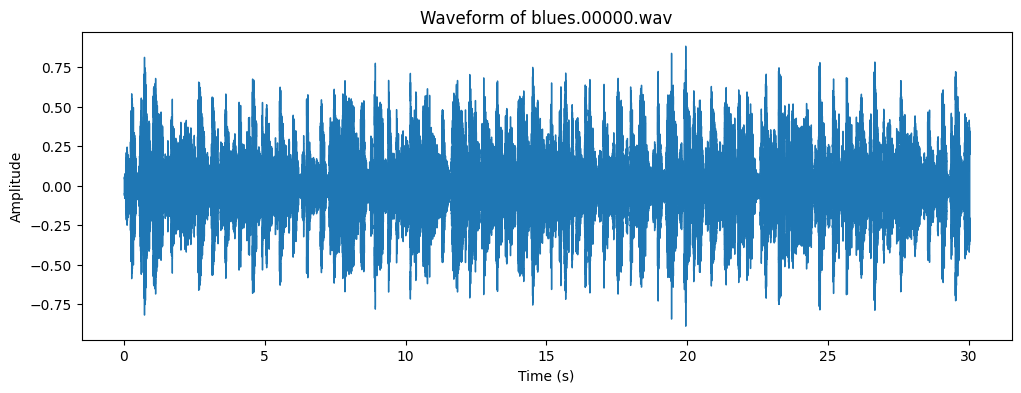

In [8]:
# Plotting the first audio file's waveform and MFCC heatmap for visualization

sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")

audio, sample_rate = librosa.load(sample_file)

plt.figure(figsize=(12, 4))
librosa.display.waveshow(audio, sr=sample_rate)
plt.title("Waveform of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

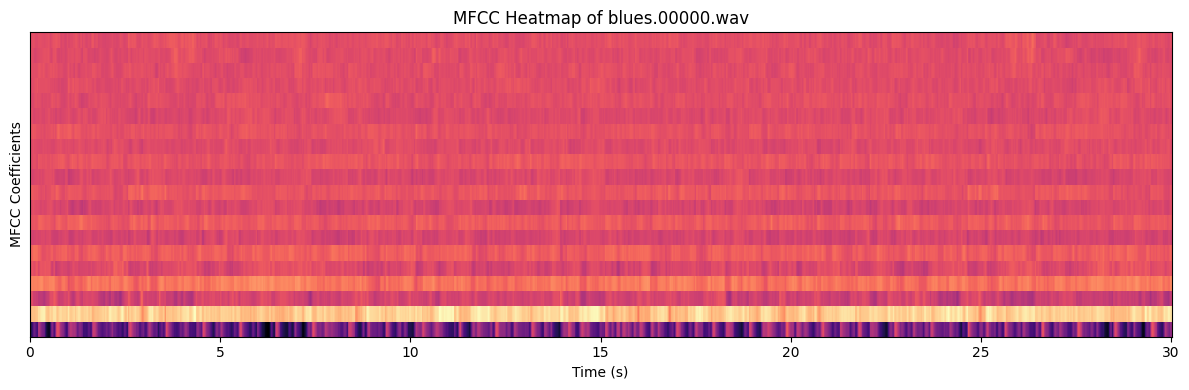

In [98]:
# Extract MFCC features for the sample file

sample_file = os.path.join(DATASET_PATH, "blues", "blues.00000.wav")
audio, sample_rate = librosa.load(sample_file)

mfcc_matrix = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=N_MFCC)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mfcc_matrix, x_axis='time', sr=sample_rate, cmap='magma')
plt.title("MFCC Heatmap of blues.00000.wav")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

In [82]:
# Encode labels
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Scale features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42,stratify=y_encoded)


In [83]:
# Train K-NN
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan', weights='distance') 
# use n_neighbors=5, because as it grows, it reduces the variance of the model, but it can also increase bias, so it can be tuned further
# instead of 'uniform' values, to give more weight to closer neighbors
# use manhattan distance instead of euclidean, as it can perform better in high-dimensional spaces
knn.fit(X_train, y_train)

# Evaluate
y_pred_knn = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred_knn, target_names=label_encoder.classes_))



Accuracy: 96.89%
              precision    recall  f1-score   support

       blues       0.99      0.97      0.98       280
   classical       0.97      0.94      0.96       279
     country       0.94      0.97      0.96       279
       disco       0.98      0.96      0.97       280
      hiphop       0.99      0.98      0.99       279
        jazz       0.94      0.97      0.96       277
       metal       0.96      0.98      0.97       280
         pop       0.99      0.98      0.99       280
      reggae       0.96      0.98      0.97       280
        rock       0.95      0.95      0.95       280

    accuracy                           0.97      2794
   macro avg       0.97      0.97      0.97      2794
weighted avg       0.97      0.97      0.97      2794



In [65]:
# Train Random Forest for testing another model, to compare results with K-NN
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Random Forest Accuracy: 87.33%
              precision    recall  f1-score   support

       blues       0.91      0.84      0.87       280
   classical       0.90      0.96      0.93       279
     country       0.81      0.80      0.81       279
       disco       0.83      0.89      0.86       280
      hiphop       0.92      0.82      0.86       279
        jazz       0.86      0.90      0.88       277
       metal       0.87      0.91      0.89       280
         pop       0.94      0.93      0.93       280
      reggae       0.85      0.91      0.88       280
        rock       0.86      0.79      0.82       280

    accuracy                           0.87      2794
   macro avg       0.87      0.87      0.87      2794
weighted avg       0.87      0.87      0.87      2794



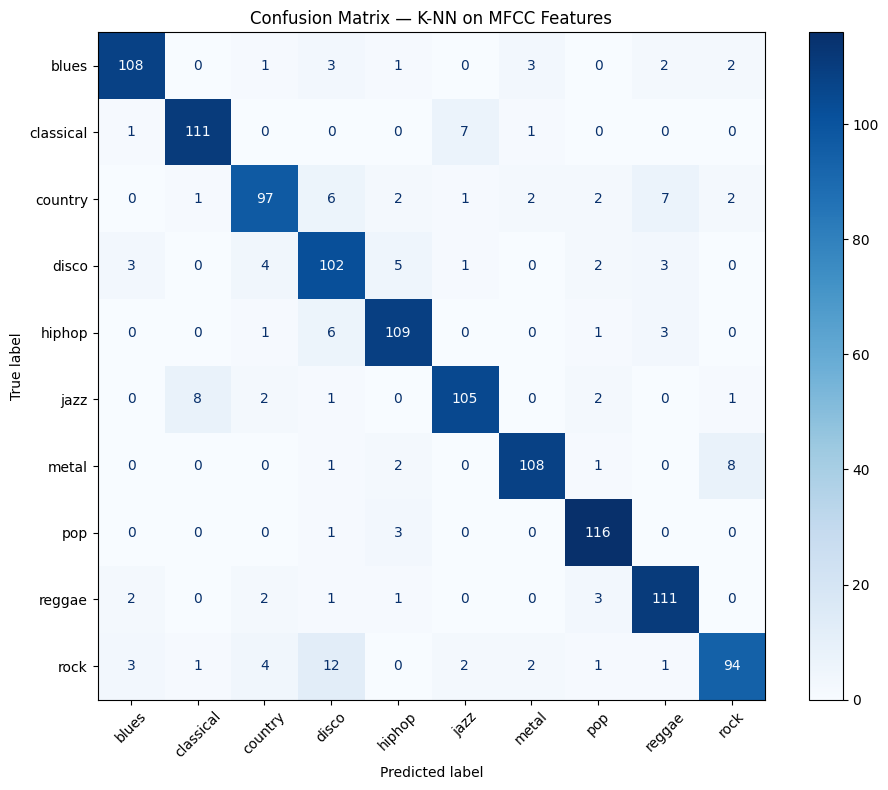

In [56]:
# Confusion matrix for K-NN

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    display_labels=label_encoder.classes_,
    cmap='Blues',
    xticks_rotation=45,
    ax=ax
)
plt.title("Confusion Matrix — K-NN on MFCC Features")
plt.tight_layout()
plt.show()

In [ ]:
def predict_genre(file_path,
                  model=knn,
                  label_encoder=label_encoder,
                  scaler=scaler,
                  n_mfcc=N_MFCC,
                  segment_duration=6.0):
    """
    Predict genre by averaging predictions over multiple segments of a WAV file.
    """

    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Could not load file: {e}")
        return None

    samples_per_segment = int(sample_rate * segment_duration)
    n_segments = len(audio) // samples_per_segment

    if n_segments == 0:
        print("Audio file is shorter than one segment.")
        return None

    segments = [
        audio[i * samples_per_segment : (i + 1) * samples_per_segment]
        for i in range(n_segments)
    ]

    predictions = []

    for segment in segments:
        features = mfcc(
            segment=segment,
            sample_rate=sample_rate,
            n_mfcc=n_mfcc
        )

        features_scaled = scaler.transform(features.reshape(1, -1))
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)

    final_prediction = max(set(predictions), key=predictions.count)
    genre = label_encoder.inverse_transform([final_prediction])[0]

    print(f"Segments analyzed: {n_segments}")

    votes = {
        label_encoder.inverse_transform([p])[0]: predictions.count(p)
        for p in set(predictions)
    }

    print(f"Votes per genre: {votes}")
    print(f"Predicted genre: {genre}")

    return genre

In [ ]:
def predict_genre_plus(file_path,
                  model=knn,
                  label_encoder=label_encoder,
                  scaler=scaler,
                  n_mfcc=N_MFCC,
                  segment_duration=10.0):
    """
    Predict genre by averaging predictions over multiple segments of a WAV file.
    """

    try:
        audio, sample_rate = librosa.load(file_path, sr=None)
    except Exception as e:
        print(f"Could not load file: {e}")
        return None

    samples_per_segment = int(sample_rate * segment_duration)
    n_segments = len(audio) // samples_per_segment

    if n_segments == 0:
        print("Audio file is shorter than one segment.")
        return None

    segments = [
        audio[i * samples_per_segment : (i + 1) * samples_per_segment]
        for i in range(n_segments)
    ]

    predictions = []

    for segment in segments:
        features = mfcc_other(
            segment=segment,
            sample_rate=sample_rate,
            n_mfcc=n_mfcc
        )

        features_scaled = scaler.transform(features.reshape(1, -1))
        pred = model.predict(features_scaled)[0]
        predictions.append(pred)

    final_prediction = max(set(predictions), key=predictions.count)
    genre = label_encoder.inverse_transform([final_prediction])[0]

    print(f"Segments analyzed: {n_segments}")

    votes = {
        label_encoder.inverse_transform([p])[0]: predictions.count(p)
        for p in set(predictions)
    }

    print(f"Votes per genre: {votes}")
    print(f"Predicted genre: {genre}")

    return genre

In [92]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav")

Segments analyzed: 23
Votes per genre: {np.str_('reggae'): 16, np.str_('classical'): 1, np.str_('hiphop'): 5, np.str_('pop'): 1}
Predicted genre: reggae


np.str_('reggae')

In [72]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Another Brick in the Wall.wav", model=rf)

Segments analyzed: 39
Votes per genre: {np.str_('reggae'): 30, np.str_('classical'): 1, np.str_('country'): 4, np.str_('blues'): 4}
Predicted genre: reggae


np.str_('reggae')

In [93]:
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\AC DC Highway to hell.wav", model=knn)

Segments analyzed: 20
Votes per genre: {np.str_('blues'): 3, np.str_('country'): 1, np.str_('disco'): 1, np.str_('hiphop'): 8, np.str_('jazz'): 1, np.str_('metal'): 5, np.str_('reggae'): 1}
Predicted genre: hiphop


np.str_('hiphop')

In [94]:
# prediction with the kNN model
predict_genre(file_path=r"C:\01_BME\05_Intro to ML\00_MusicGenre\Anastacia - I'm outta love.wav", model=knn)

Segments analyzed: 23
Votes per genre: {np.str_('blues'): 2, np.str_('country'): 1, np.str_('disco'): 4, np.str_('hiphop'): 11, np.str_('pop'): 1, np.str_('reggae'): 4}
Predicted genre: hiphop


np.str_('hiphop')

In [ ]:
# tsne